<a href="https://colab.research.google.com/github/pauloricardo2-alt/lia1_2026_1/blob/main/Aula-09-e-Projetos_Alunos/Primeiro_Modelo_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## <font color='Blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow</font>

Construir um modelo de Inteligência Artificial capaz de classificar imagens considerando 10 categorias: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'].
 Dada uma nova imagem de uma dessas categorias o modelo deve ser capaz de classificar e indicar o que é a imagem. <font color='red'>Lembrando: uma imagem é uma matriz de pixels!</font>

Conheça o TensorFlow! -> https://www.tensorflow.org/

SyntaxError: invalid syntax (2749940140.py, line 3)

In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [ ]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow


In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image


## Carregando os dados - matéria prima
https://www.cs.toronto.edu/~kriz/cifar.html

In [ ]:
# Carrega o dataset CIFAR-10 - Já está no Keras!
(imagens_treino, labels_treino), (imagens_teste, labels_teste) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


In [ ]:
# Classes das imagens
nomes_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# Normaliza os valores dos pixels para que os dados fiquem na mesma escala
imagens_treino = imagens_treino / 255.0
imagens_teste = imagens_teste / 255.0

In [ ]:
# Função para exibir as imagens
def visualiza_imagens(images, labels):
    plt.figure(figsize = (10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap = plt.cm.binary)
        plt.xlabel(nomes_classes[labels[i][0]])
    plt.show()


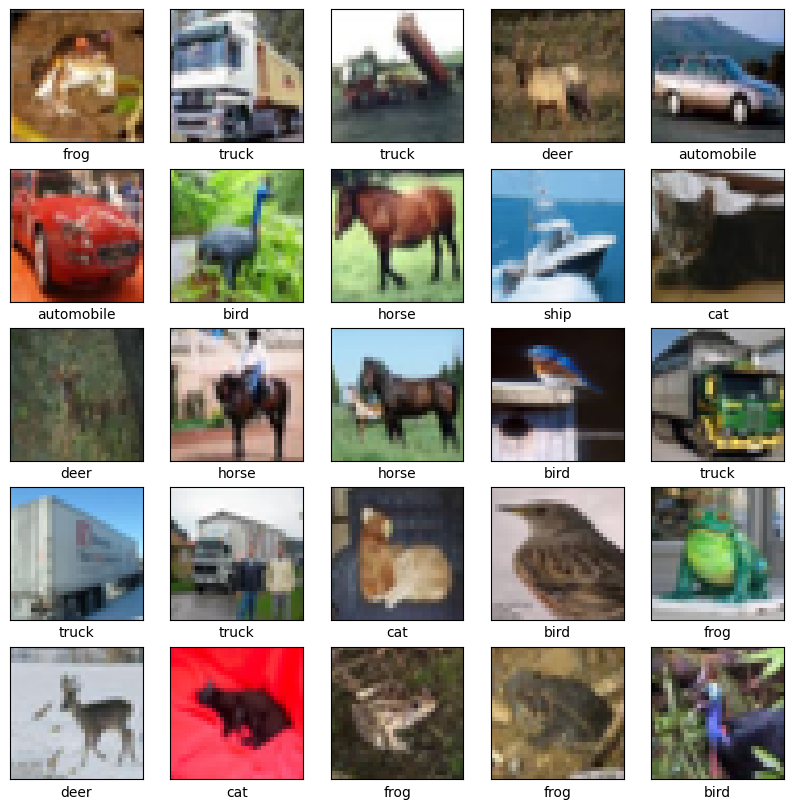

In [ ]:
# Executa a função
#Imagens de trino
visualiza_imagens(imagens_treino, labels_treino)

In [ ]:
#AGR que tem tudo, vai criar o modelo

## Construção do Modelo


In [ ]:
#Tem 3 camadas por que é RGB# Arquitetura do Modelo -> Feature Learning

from tensorflow.keras import models, layers

modelo_lia = models.Sequential()

# Camada de entrada
modelo_lia.add(layers.Input(shape=(32, 32, 3)))

# Blocos convolucionais + pooling
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

In [ ]:
# Adicionar camadas de classificação - Converte para um vetor - flatten
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(64, activation = 'relu'))
modelo_lia.add(layers.Dense(10, activation = 'softmax'))


In [ ]:
#Vamo ver se a nossa aquitetura ta ok

In [ ]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,418 (286.79 KB)

 Trainable params: 73,418 (286.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#O deepseek tem 700 Bilhoes de parâmetros
#Vai usar a métrica de acurácia para ver o sucesso do modelo
#Não existe modelo com 100% e nem com 0%
#se ficar muito perto de 100%, desconfiar
#O olo humano da 70# em cancewr de pulmao, as IAs tem 90%
# Compilação do modelo
modelo_lia.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

# adam - é um algoritmo de aprendizagem tipo backpropagation!
# loss - função de erro. Isso se resume a uma otimização função matemática!
# metrics - medir o sucesso!


In [ ]:
#epochs é as temporadas, quantas vezes tem que passar por todo o dataset pra aperfeiçoar
#abaixo de 100 é brincadeira de criança

In [ ]:
#Quanto mais ele roda, mais aprende, mais tem um momento em que ele começa a desaprender
#Ele desaptrnde por que pode começar a viciar e a tender
#Pode ser que o dataset seja desbalanceado, tipo 1000 de
#Overfit
%%time
history = modelo_lia.fit(imagens_treino,
                         labels_treino,
                         epochs = 5,
                         validation_data = (imagens_teste, labels_teste))


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 40ms/step - accuracy: 0.3794 - loss: 1.7577 - val_accuracy: 0.4489 - val_loss: 1.5093
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.5153 - loss: 1.3585 - val_accuracy: 0.5394 - val_loss: 1.3080
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.5771 - loss: 1.1930 - val_accuracy: 0.5835 - val_loss: 1.1900
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6183 - loss: 1.0868 - val_accuracy: 0.6005 - val_loss: 1.1498
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6498 - loss: 1.0057 - val_accuracy: 0.6336 - val_loss: 1.0620
CPU times: user 7min 56s, sys: 7.75 s, total: 8min 3s
Wall time: 5min 48s


## Avaliação do modelo

In [ ]:
# Avalia o modelo
erro_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose = 2)


313/313 - 3s - 11ms/step - accuracy: 0.6336 - loss: 1.0620


In [ ]:
print('\nAcurácia com dados de Teste:', acc_teste)


Acurácia com dados de Teste: 0.6335999965667725


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


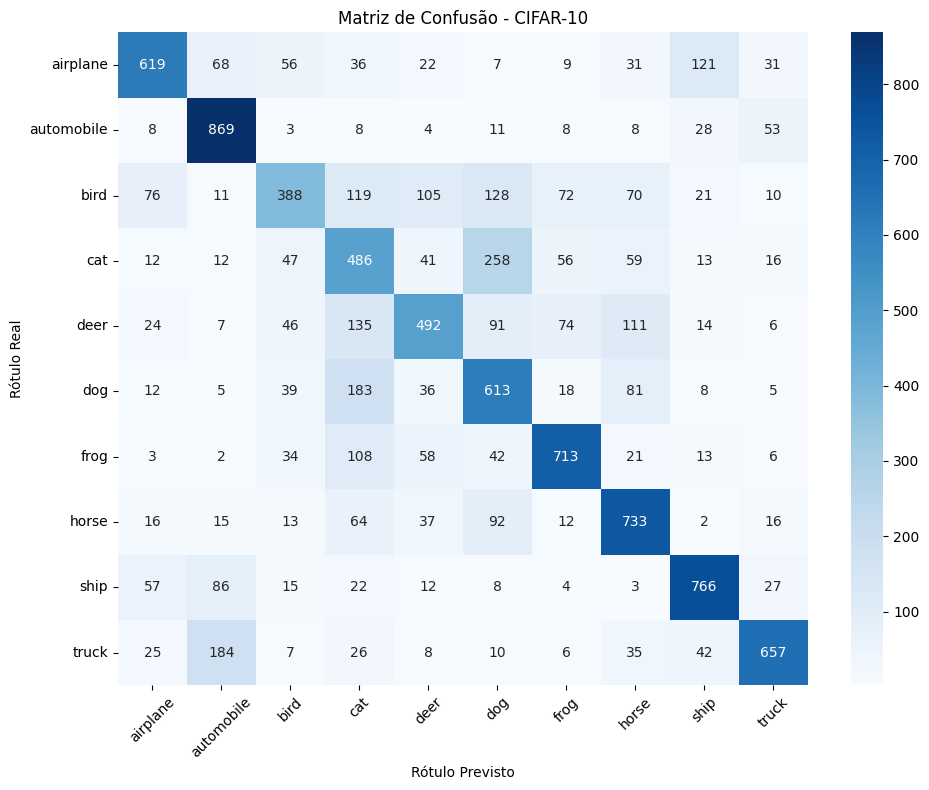

In [ ]:
# Imprime a matriz de confusão
from sklearn.metrics import confusion_matrix

# Previsão do modelo
y_pred = modelo_lia.predict(imagens_teste)
y_pred_classes = np.argmax(y_pred, axis=1)

# Labels já estão no formato inteiro, então podemos usá-las diretamente
y_true = labels_teste.flatten()  # Caso labels_teste tenha shape (10000, 1)

# Geração da matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

# Impressão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)
plt.title('Matriz de Confusão - CIFAR-10')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:

#Das 10000 iamgens de truck ele falou que 25 eram de avião, 184 falou que era autoóvel
#Matriz de confusão tem que ser a 1a coisa a fazer dpw que rodar o código
#Se gato se confundi mt com cachorro, o contrario tem que ser verdadeiro, por que se nao for, o problema é nos dados

In [ ]:
# Carrega uma nova imagem
nova_imagem = Image.open("/content/images.jpg")

In [ ]:

# Dimensões da imagem (em pixels)
nova_imagem.size

# Obtém largura e altura da imagem
largura = nova_imagem.width
altura = nova_imagem.height

In [ ]:
print("A largura da imagem é: ", largura)
print("A altura da imagem é: ", altura)

A largura da imagem é:  278
A altura da imagem é:  181


In [ ]:
# Redimensiona para 32x32 pixels
nova_imagem = nova_imagem.resize((32, 32))



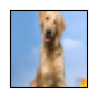

In [ ]:
# Exibir a imagem
plt.figure(figsize = (1,1))
plt.imshow(nova_imagem)
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
# Converte a imagem para um array NumPy e normaliza
nova_imagem_array = np.array(nova_imagem) / 255.0

In [ ]:
# Expande a dimensão do array para que ele tenha o formato (1, 32, 32, 3)
nova_imagem_array = np.expand_dims(nova_imagem_array, axis = 0)


In [ ]:

# Previsões
previsoes = modelo_lia.predict(nova_imagem_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
print(previsoes)

[[0.0285125  0.02212558 0.14921327 0.130137   0.26174098 0.07541526
  0.17378692 0.04901637 0.08301909 0.02703301]]


In [ ]:
# Obtém a classe com maior probabilidade e o nome da classe
classe_prevista = np.argmax(previsoes)
nome_classe_prevista = nomes_classes[classe_prevista]



In [ ]:
print("A nova imagem foi classificada como:", nome_classe_prevista)

A nova imagem foi classificada como: deer
